**Importing libraries and Exploring the Dataset.**



In [217]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



df = pd.read_csv('Titanic_train.csv')
test_set = pd.read_csv('Titanic_test.csv')

 **Definining Exploratory Data Analysis with an overview of the whole project**

In [218]:
df.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [220]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Check for Dublicates**

In [221]:
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


**Visualization & Analysis**




**Univariate Analysis**

**Check for bias**

In [222]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

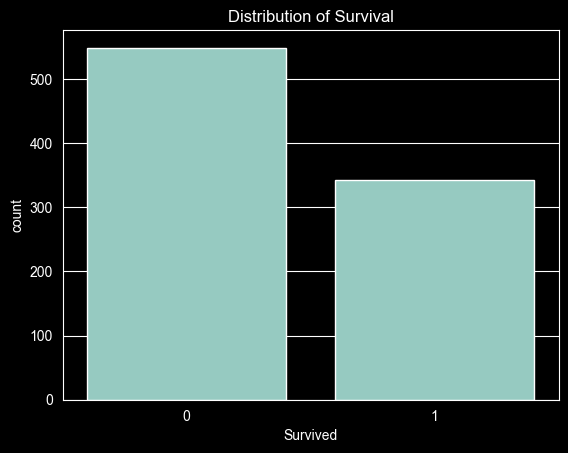

In [223]:
sns.countplot(x='Survived', data=df)
plt.title("Distribution of Survival")
plt.show()

The distribution of the target variable shows that the dataset is slightly imbalanced, with a higher number of passengers who did not survive compared to those who survived.

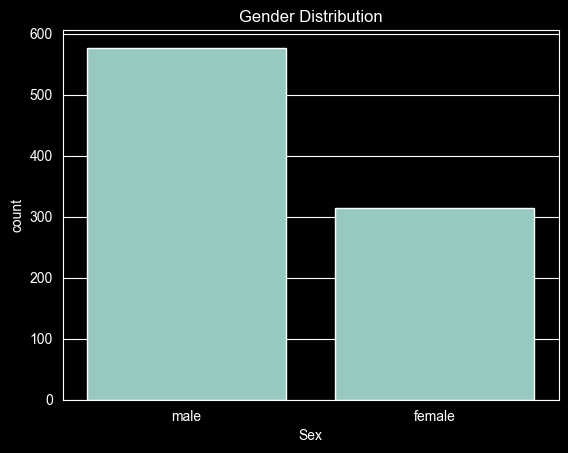

In [224]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

The dataset contains more male passengers than female passengers.

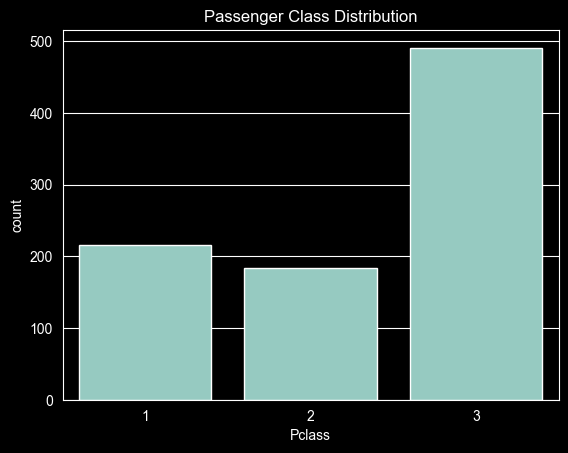

In [225]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

Most passengers belong to the third class, followed by first and second classes. This indicates that the dataset is dominated by lower socioeconomic groups.

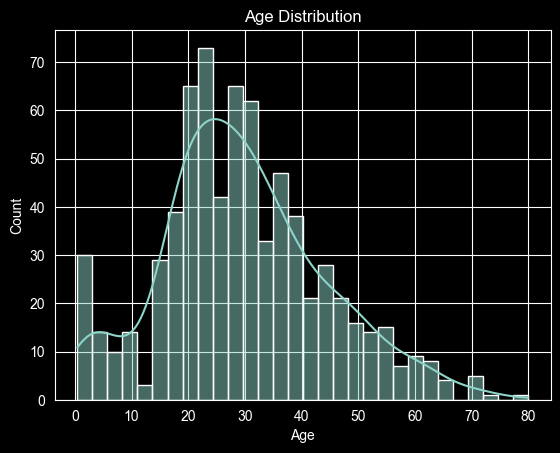

In [226]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

The age distribution is right-skewed, with most passengers being young adults. There are fewer elderly passengers, and a small number of children are present in the dataset.

**Bivariate Analysis (Relation With Survived)**

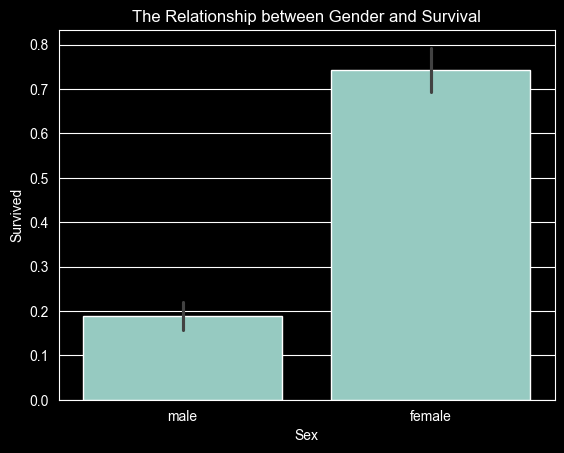

In [227]:
sns.barplot(x='Sex',y='Survived', data=df)
plt.title("The Relationship between Gender and Survival")
plt.show()

Female passengers have a significantly higher survival rate compared to male passengers. This suggests that gender is a strong predictor of survival, likely due to evacuation priority policies.

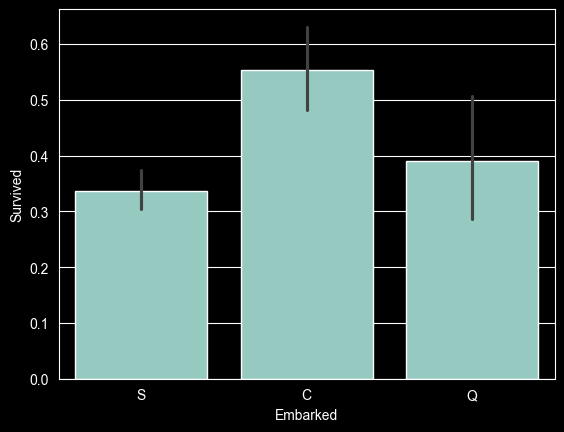

In [228]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.show()

Embarked was retained as it may have an indirect impact on survival based on passenger distribution across ports.

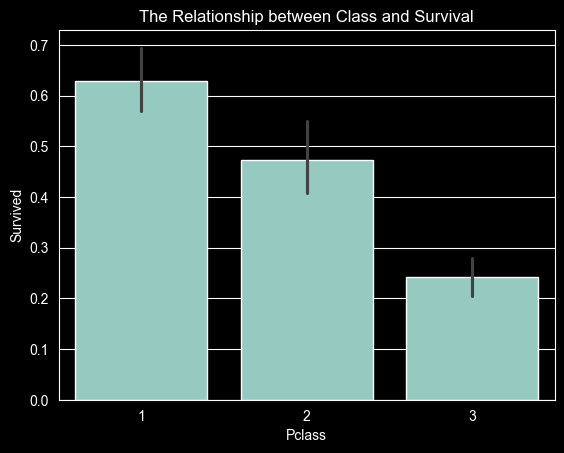

In [229]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("The Relationship between Class and Survival")
plt.show()

Passengers in higher classes (especially first class) have a higher survival rate compared to those in lower classes. This indicates that socioeconomic status played a key role in survival.

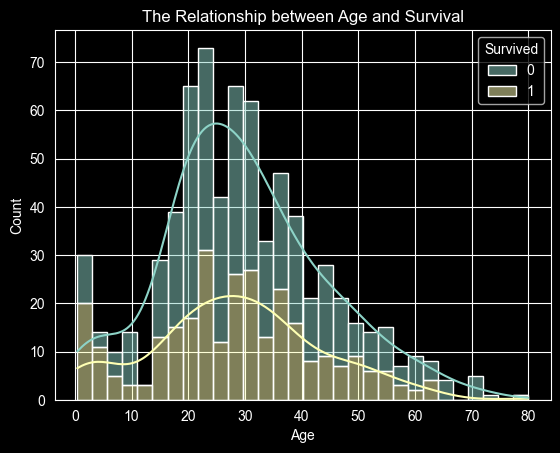

In [230]:
sns.histplot(x='Age',hue='Survived', bins=30, data=df, multiple="stack", kde=True)
plt.title("The Relationship between Age and Survival")
plt.show()

Younger passengers, especially children, appear to have a higher survival rate. In contrast, middle-aged individuals show a lower survival probability.

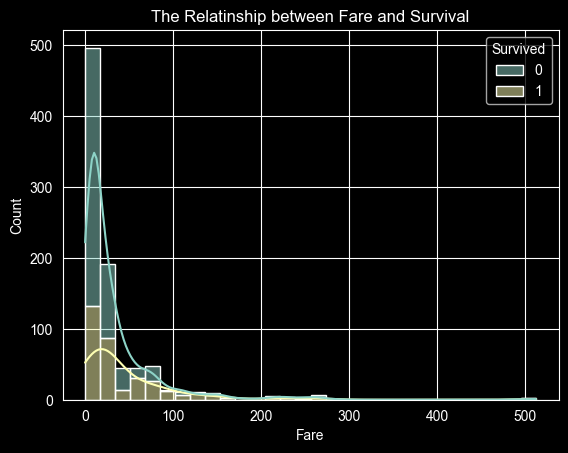

In [231]:
sns.histplot(x='Fare', hue='Survived', bins=30, kde=True, multiple="stack", data=df)
plt.title("The Relatinship between Fare and Survival")
plt.show()

Passengers who paid higher fares tend to have higher survival rates. This further supports the idea that wealth and class influenced survival chances.

**Detecting Correlation**

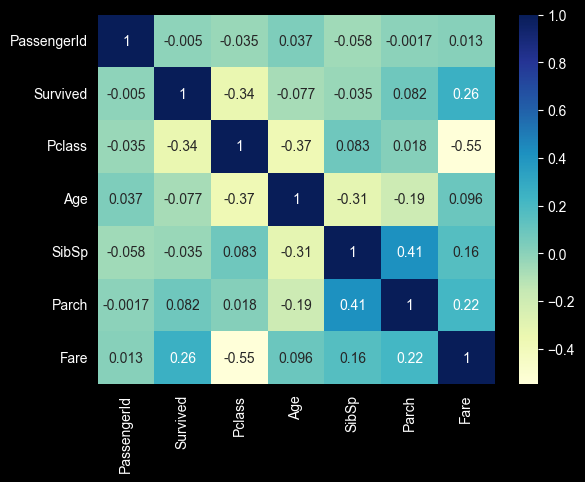

In [232]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.show()

**Spliting data (Stratified Sampling)**

In [233]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [234]:
for train_idx, val_idx in split.split(df, df["Survived"]):
  train_set = df.iloc[train_idx]
  val_set = df.iloc[val_idx]

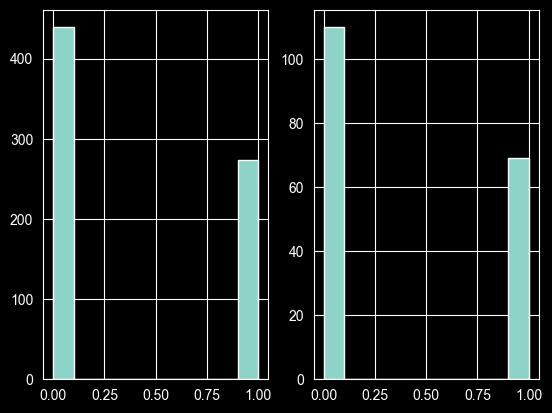

In [235]:
plt.subplot (1,2,1)
train_set ['Survived'].hist ()

plt.subplot (1,2,2)
val_set['Survived'].hist ()

plt.show()

In [236]:
print(train_set["Survived"].value_counts(normalize=True))
print(val_set["Survived"].value_counts(normalize=True))

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


**Avoiding Data Leakage by Copying Datasets**

In [237]:
train_set = train_set.copy()
val_set = val_set.copy()
test_set = test_set.copy()

**Feature Engineering**

In [238]:
train_set.loc[:, 'FamilySize'] = train_set['SibSp'] + train_set['Parch'] + 1
val_set.loc[:, 'FamilySize'] = val_set['SibSp'] + val_set['Parch'] + 1
test_set.loc[:, 'FamilySize'] = test_set['SibSp'] + test_set['Parch'] + 1

In [239]:
train_set.loc[:, 'IsAlone'] = (train_set['FamilySize'] == 1).astype(int)
val_set.loc[:, 'IsAlone'] = (val_set['FamilySize'] == 1).astype(int)
test_set.loc[:, 'IsAlone'] = (test_set['FamilySize'] == 1).astype(int)

In [240]:
train_set.loc[:, 'Title'] = train_set['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
val_set.loc[:, 'Title'] = val_set['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_set.loc[:, 'Title'] = test_set['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

**Reducing Title Cardinality by Merging Rare Titles (Title mapping)**

In [241]:
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Other', 'Sir': 'Other', 'Countess': 'Other', 'Jonkheer': 'Other',
    'Don': 'Other', 'Dona': 'Other', 'Rev': 'Other', 'Dr': 'Other',
    'Capt': 'Other', 'Col': 'Other', 'Major': 'Other'
}

train_set['Title'] = train_set['Title'].replace(title_mapping)
val_set['Title'] = val_set['Title'].replace(title_mapping)
test_set['Title'] = test_set['Title'].replace(title_mapping)

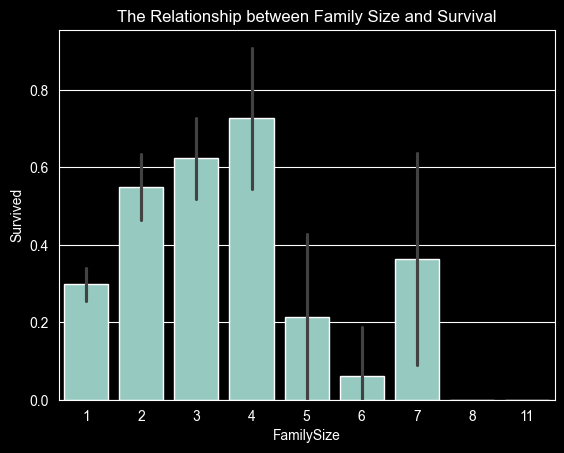

In [242]:
sns.barplot(x='FamilySize', y='Survived',data= train_set)
plt.title("The Relationship between Family Size and Survival")
plt.show()

Passengers with small family sizes tend to have higher survival rates, while very large families show lower survival probabilities.

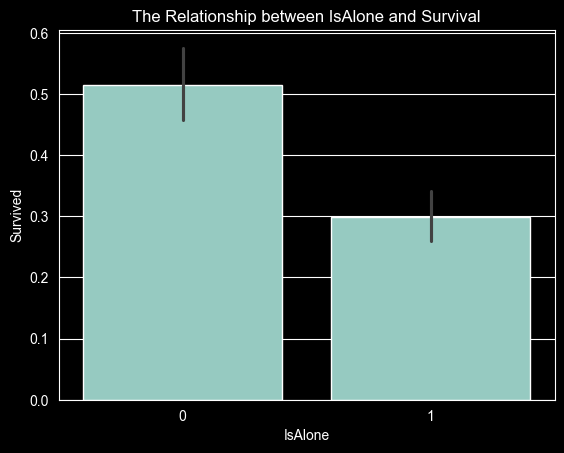

In [243]:
sns.barplot(x='IsAlone', y='Survived', data= train_set)
plt.title("The Relationship between IsAlone and Survival")
plt.show()

Passengers traveling alone have a lower survival rate compared to those traveling with family members.

**Handling Missing Values**

In [244]:
train_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
FamilySize       0
IsAlone          0
Title            0
dtype: int64

In [245]:
val_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             40
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          135
Embarked         0
FamilySize       0
IsAlone          0
Title            0
dtype: int64

In [246]:
age_medians = train_set.groupby('Title')['Age'].median()

train_set['Age'] = train_set['Age'].fillna(
    train_set['Title'].map(age_medians)
)

val_set['Age'] = val_set['Age'].fillna(
    val_set['Title'].map(age_medians)
)

test_set['Age'] = test_set['Age'].fillna(
    test_set['Title'].map(age_medians)
)
# If Title-based median is not available, use global median from training data
test_set['Age'] = test_set['Age'].fillna(train_set['Age'].median())

val_set['Age'] = val_set['Age'].fillna(train_set['Age'].median())

In [247]:
mode_embarked = train_set['Embarked'].mode()[0]

train_set.loc[:,'Embarked'] = train_set['Embarked'].fillna(mode_embarked)
val_set.loc[:,'Embarked'] = val_set['Embarked'].fillna(mode_embarked)
test_set.loc[:, 'Embarked'] = test_set['Embarked'].fillna(mode_embarked)

In [248]:
test_set['Fare'] = test_set['Fare'].fillna(train_set['Fare'].median())

**Encoding**

Categorical variable 'Embarked' was encoded using One-Hot Encoding to convert categorical values into numerical format suitable for machine learning models.

In [249]:
train_set = pd.get_dummies(train_set, columns=['Embarked', 'Title'])
val_set = pd.get_dummies(val_set, columns=['Embarked', 'Title'])
test_set = pd.get_dummies(test_set, columns=['Embarked', 'Title'])

In [250]:
train_set['Sex'] = train_set['Sex'].map({'male':0, 'female':1})
val_set['Sex'] = val_set['Sex'].map({'male':0, 'female':1})
test_set['Sex'] = test_set['Sex'].map({'male':0, 'female':1})

**Feature Dropping**

In [251]:
cols_to_drop = ['Name','Ticket','Cabin','PassengerId']

train_set.drop(cols_to_drop, axis=1, inplace=True)
val_set.drop(cols_to_drop, axis=1, inplace=True)
test_set.drop(cols_to_drop, axis=1, inplace=True)

**Ensuring Consistent Feature Structure Between Train,Test and Validation Sets**

In [252]:
val_set = val_set.reindex(columns=train_set.columns, fill_value=0)
test_set = test_set.reindex(columns=train_set.drop('Survived', axis=1).columns, fill_value=0)

**Handling Outliers**

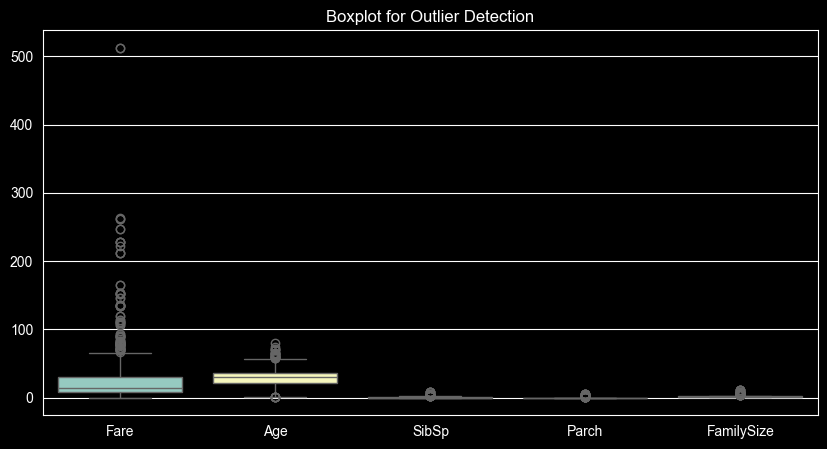

In [253]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train_set[['Fare', 'Age', 'SibSp', 'Parch','FamilySize']])
plt.title("Boxplot for Outlier Detection")
plt.show()

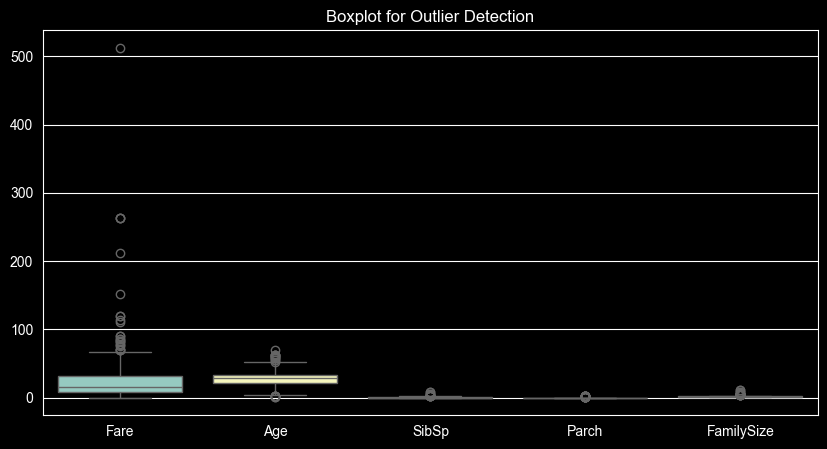

In [254]:
plt.figure(figsize=(10,5))
sns.boxplot(data=val_set[['Fare', 'Age', 'SibSp', 'Parch',"FamilySize"]])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [255]:
# Q1 = train_set['Fare'].quantile(0.25)
# Q3 = train_set['Fare'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# train_set['Fare'] = train_set['Fare'].clip(lower, upper)
# val_set['Fare'] = val_set['Fare'].clip(lower, upper)
# test_set['Fare'] = test_set['Fare'].clip(lower, upper)

In [256]:
# Q1 = train_set['Age'].quantile(0.25)
# Q3 = train_set['Age'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# train_set['Age'] = train_set['Age'].clip(lower, upper)
# val_set['Age'] = val_set['Age'].clip(lower, upper)
# test_set['Age'] = test_set['Age'].clip(lower, upper)

**Feature Scaling**

In [257]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
scaler = StandardScaler()

train_set[cols_to_scale] = scaler.fit_transform(train_set[cols_to_scale])

val_set[cols_to_scale] = scaler.transform(val_set[cols_to_scale])
test_set[cols_to_scale] = scaler.transform(test_set[cols_to_scale])

In [258]:
train_set.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
692,1,3,0,0.033471,-0.465084,-0.466183,0.513812,-0.556339,1,False,False,True,False,False,True,False,False
481,0,2,0,0.033471,-0.465084,-0.466183,-0.662563,-0.556339,1,False,False,True,False,False,True,False,False
527,0,1,0,0.033471,-0.465084,-0.466183,3.955399,-0.556339,1,False,False,True,False,False,True,False,False
855,1,3,1,-0.872714,-0.465084,0.727782,-0.467874,0.073412,0,False,False,True,False,False,False,True,False
801,1,2,1,0.108986,0.478335,0.727782,-0.115977,0.703162,0,False,False,True,False,False,False,True,False


**Decision Tree 🌳**

In [259]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree


In [260]:
y_train = train_set['Survived']
y_val = val_set['Survived']
X_train = train_set.drop('Survived', axis=1)
X_val = val_set.drop('Survived', axis=1)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [261]:
y_pred = dt_model.predict(X_val)
print(f'Accuracy: {accuracy_score(y_val, y_pred)*100:.2f}%')
print(classification_report(y_val, y_pred))

Accuracy: 81.01%
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



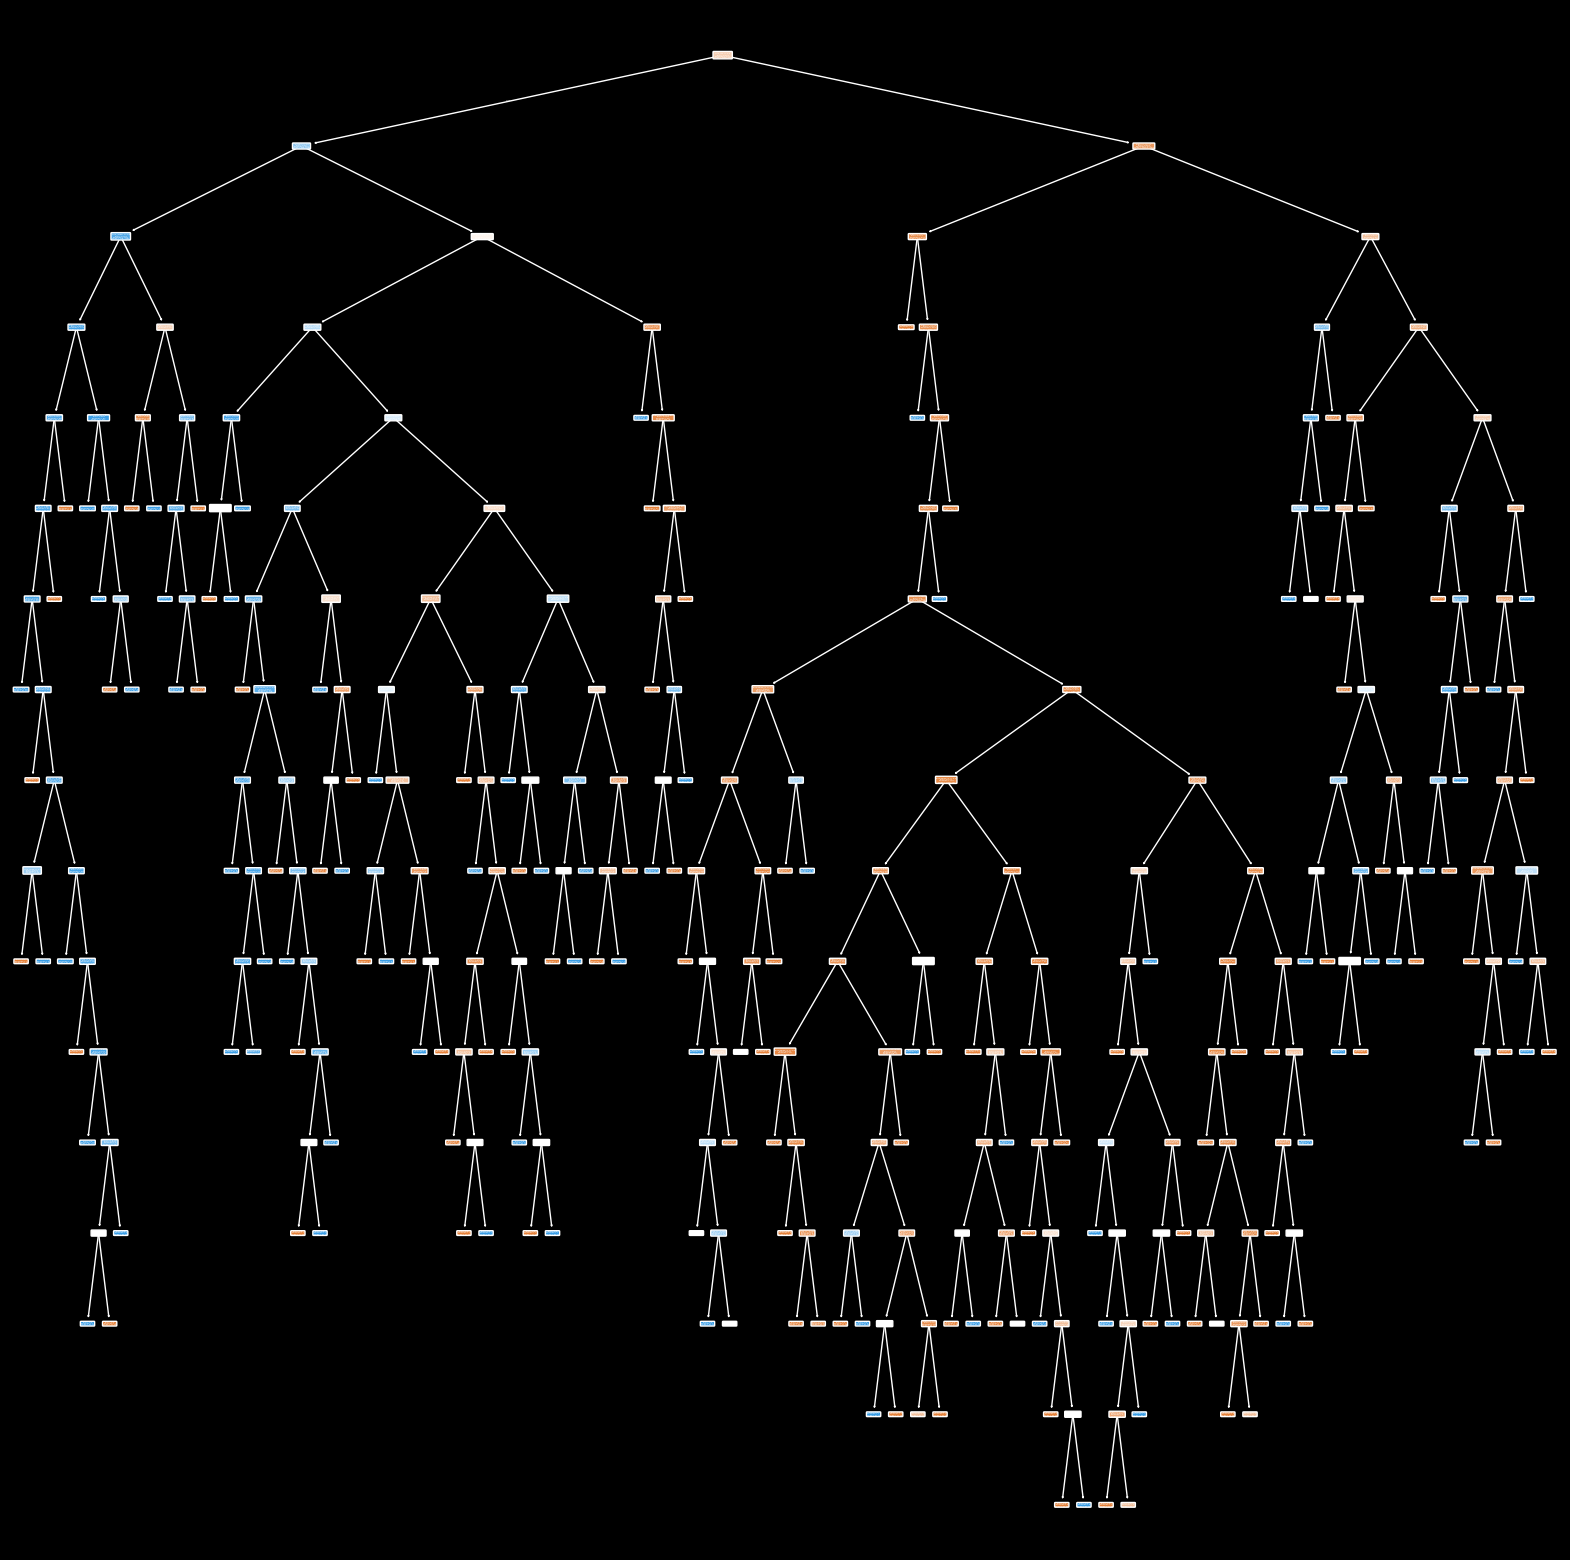

In [262]:
plt.figure(figsize=(20,20))
plot_tree(dt_model,filled=True,rounded=True,feature_names=X_train.columns)
plt.show()

In [263]:
print(dt_model.get_depth())

16


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
>>>>>>>>>>>>>>>>>>>>>>>>>>

Accuracy1:83.24 % 



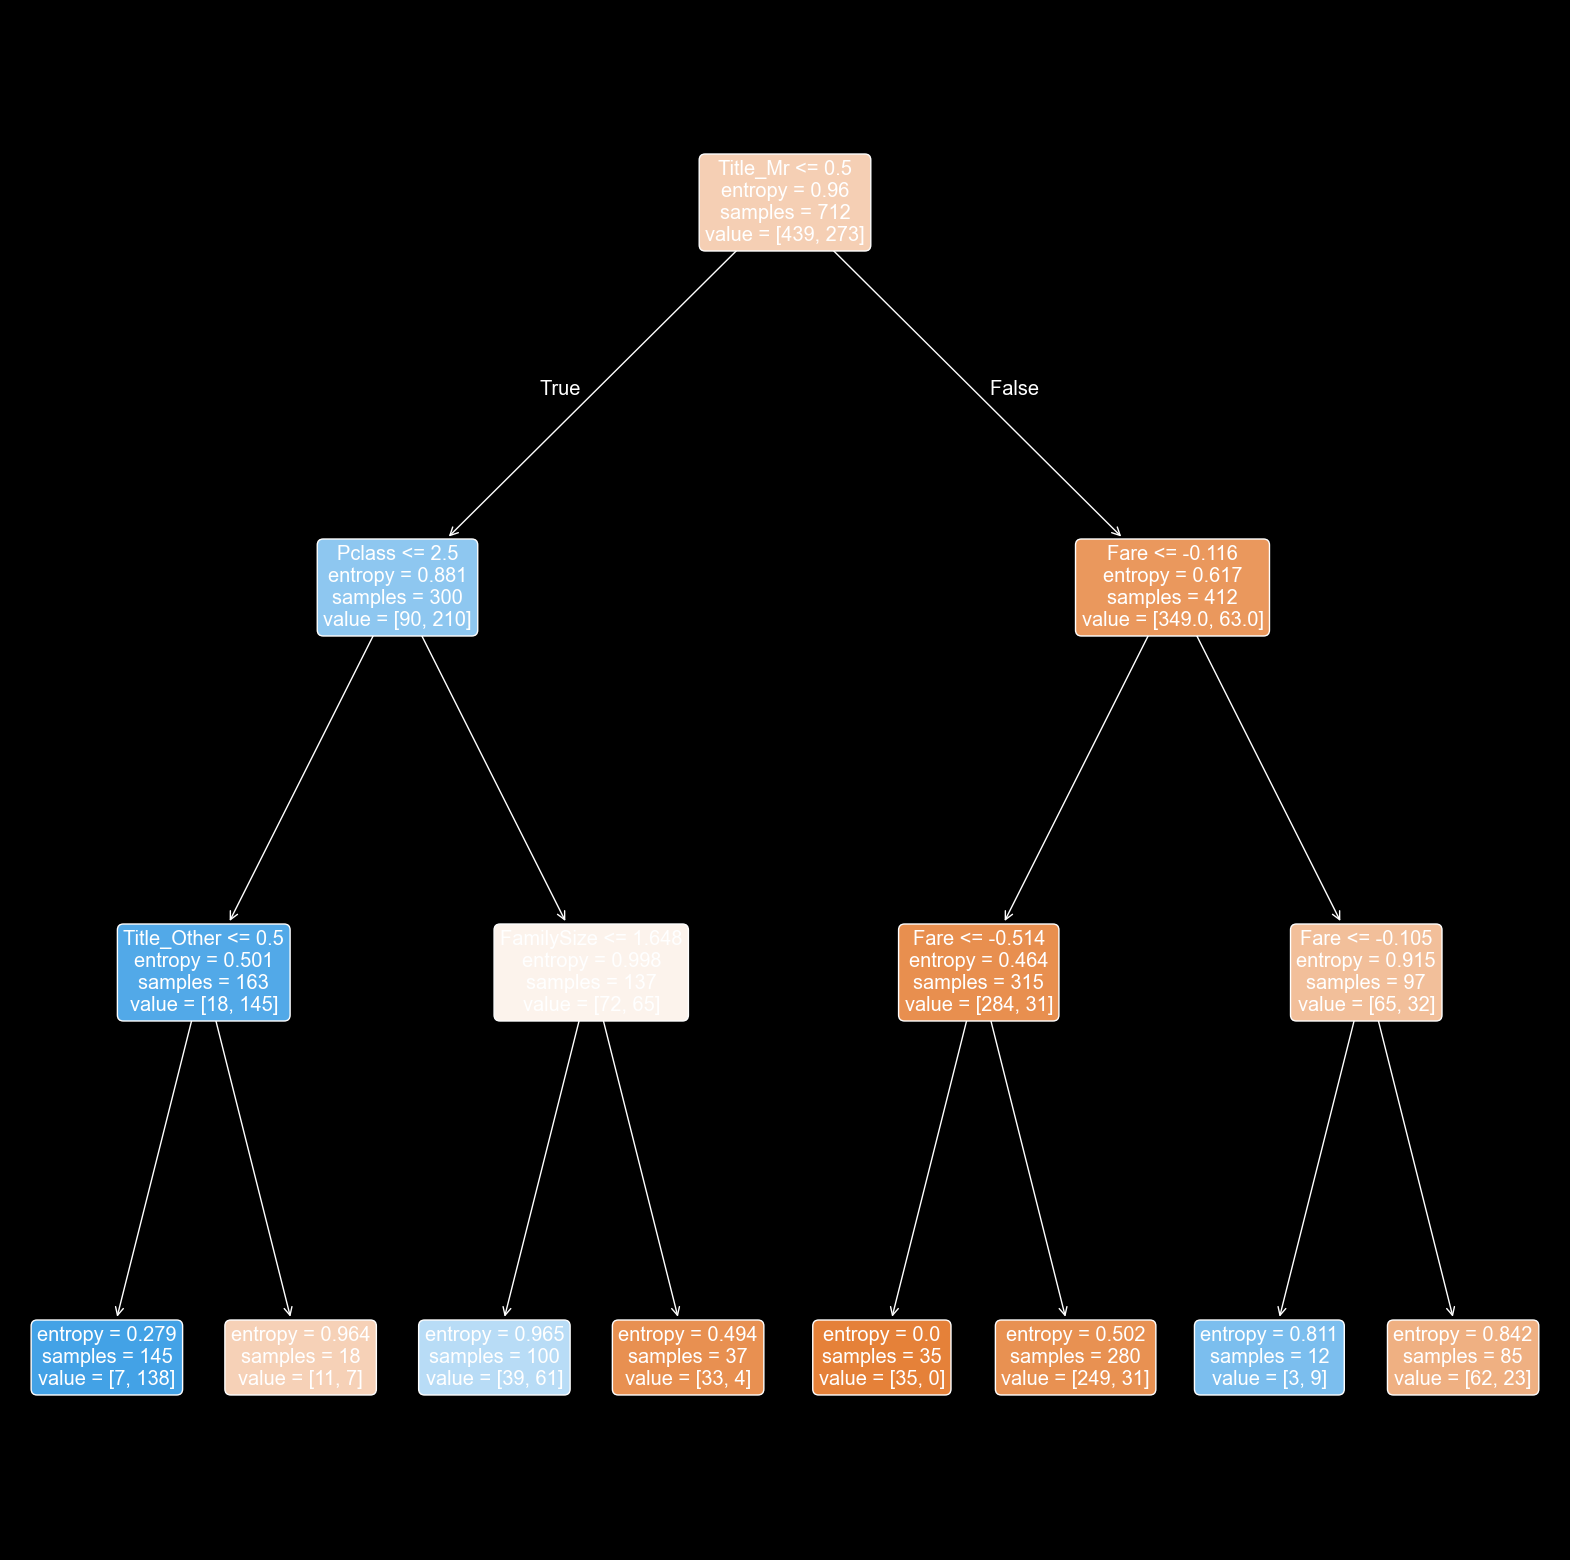

In [264]:
parameters_grid={
    'max_depth':[3,5,7],
    'min_samples_split':[2,3,4],
    'min_samples_leaf':[1,2,3],
    'criterion':['entropy']
    #الtuning by defualt بيحسب ال purity by gini ...فعن طريق ال criterion بحدد له عايزه تقيمة الشجرة على اساس اى و هو ال entropy
}

tuning=GridSearchCV(
    estimator=dt_model,
    param_grid=parameters_grid,
    cv=5,
    scoring='accuracy'
)

tuning.fit(X_train, y_train)
yPredict=tuning.predict(X_val)
dt_model1=tuning.best_estimator_
print(f'Best Parameters: {tuning.best_params_}')
print(">>>>>>>>>>>>>>>>>>>>>>>>>>\n")
print(f'Accuracy1:{accuracy_score(y_val, yPredict)*100:.2f} % \n')

##################################################################

plt.figure(figsize=(20,20))
plot_tree(dt_model1,filled=True,rounded=True,feature_names=X_train.columns)
plt.show()

Accuracy2:76.54 %



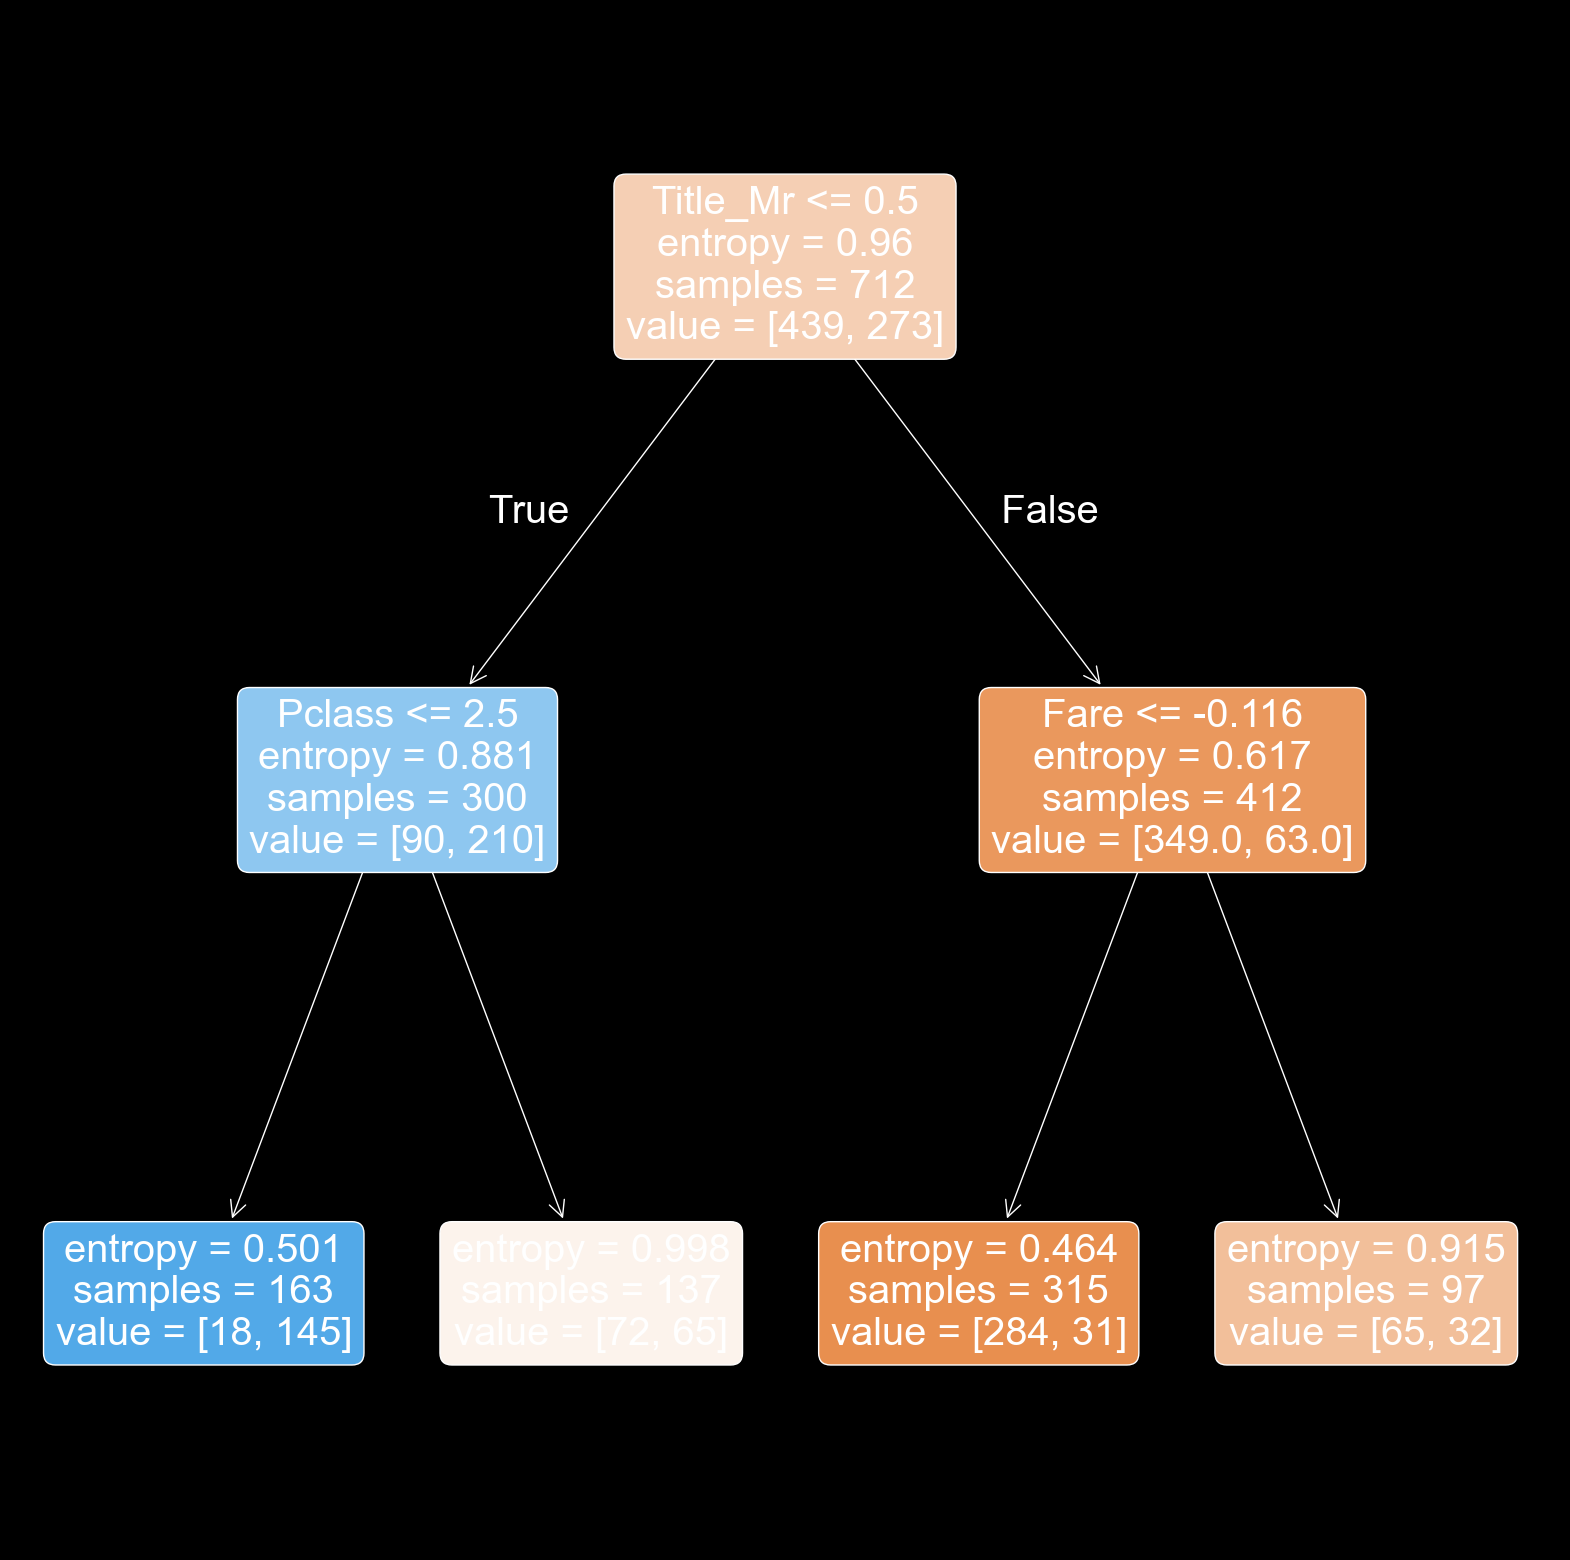

In [265]:
dt_Model2=DecisionTreeClassifier(criterion='entropy',max_depth=2,min_samples_split=2,min_samples_leaf=1,random_state=42)
#جربت كدة احط اى parameters و طلعت دقة اقل بكتير 👆
dt_Model2.fit(X_train, y_train)
yPredict2=dt_Model2.predict(X_val)
print(f'Accuracy2:{accuracy_score(y_val, yPredict2)*100:.2f} %\n')
#بيقارن النتايج بتاعة ال y_validate مع النتايج اللى طلعت لى من ال تنبؤ اصلا و على الاساس ده يحدد ال acccuracy 👆

plt.figure(figsize=(20,20))
plot_tree(dt_Model2,filled=True,rounded=True,feature_names=X_train.columns)
plt.show()


**Prediction on Test Set**

In [266]:
test_prid=dt_model1.predict(test_set)
print(test_prid[:15])

[0 1 0 0 1 0 1 0 1 0 0 0 1 0 1]


In [267]:
import joblib
joblib.dump(dt_model1, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns, "columns.pkl")

['columns.pkl']

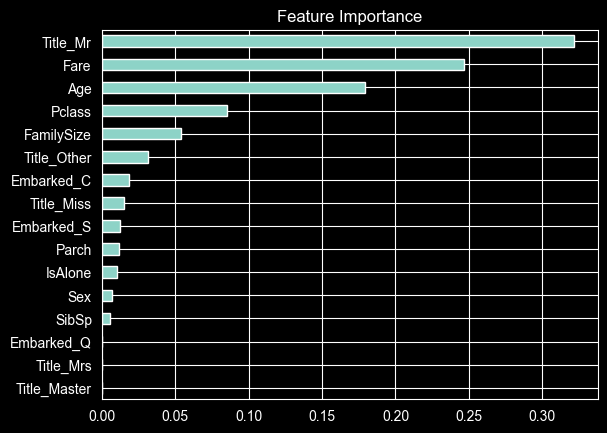

In [268]:
importance = dt_model.feature_importances_
features = X_train.columns
pd.Series(importance, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

**SVM**

In [269]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [270]:
### Building the Pipeline and Defining Hyperparameters

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C': [1, 10],
    'svm__kernel': ['linear', 'rbf'],

}

In [271]:
### Executing Grid Search to Find the Best Model
# Grid Search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'svm__C': 10, 'svm__kernel': 'linear'}


In [272]:
# Prediction
y_pred = best_model.predict(X_val)

In [273]:
# Evaluation
print(f"\nAccuracy: {accuracy_score(y_val, y_pred)*100:.4f} %")
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Accuracy: 82.6816 %

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86       110
           1       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



In [274]:
print(y_pred[:10])

[0 0 0 0 1 1 1 0 0 0]


**Prediction on Test Set on svm**

In [275]:
test_prid_svm=best_model.predict(test_set)
print(test_prid[:10])

[0 1 0 0 1 0 1 0 1 0]


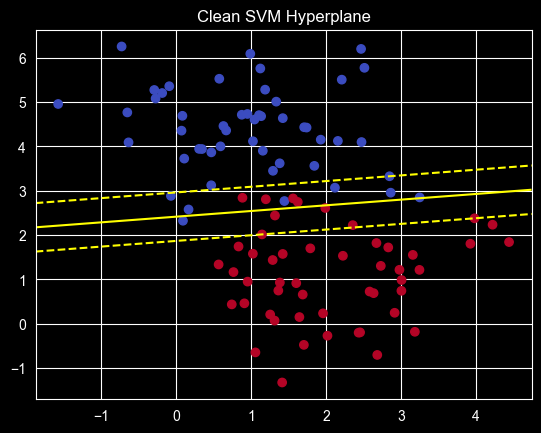

In [276]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=0)

model = SVC(kernel='linear')
model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, levels=[-1, 0, 1],
           colors='yellow',
           linestyles=['--', '-', '--'])

plt.title("Clean SVM Hyperplane")
plt.show()

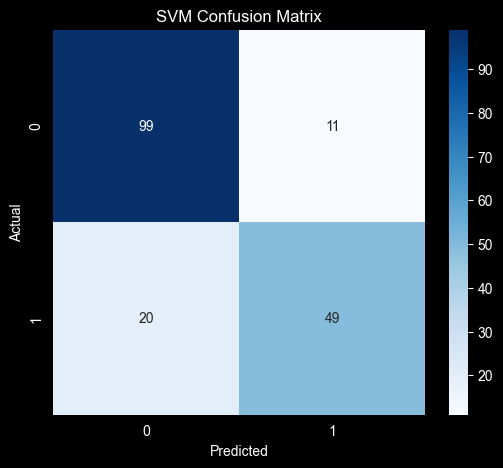

In [277]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

**Logistic Regression**

In [278]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV , StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [279]:
#هنا انا بشوف دقة الموديل من قبل ما اعمل Hyperparameter Tuning 👇

lr_test=LogisticRegression()
lr_test.fit(X_train, y_train)
yPridect=lr_test.predict(X_val)

acc_score = accuracy_score(y_val, yPridect)

print(f'Accuracy score : {acc_score * 100:.2f}%')


Accuracy score : 85.47%


In [280]:
parameters_val = {'C': [0.01, 0.1, 1, 10, 100],
                  'penalty': ['l1','l2'],
                  'solver': ['liblinear', 'saga']}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(LogisticRegression(random_state=42,max_iter=1000), parameters_val, scoring='accuracy',
    refit=True, cv=skf)
grid.fit(X_train, y_train)
best_param=grid.best_params_
best_param

C:\Users\LOQ\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\LOQ\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\LOQ\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.

{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

In [281]:
"""train_sc = grid.best_estimator_.score(x_train, y_train)
print(f'Accuracy score : {train_sc * 100:.2f}%')
grid.cv_results_['std_test_score']"""

"train_sc = grid.best_estimator_.score(x_train, y_train)\nprint(f'Accuracy score : {train_sc * 100:.2f}%')\ngrid.cv_results_['std_test_score']"

In [282]:
y_Valpredict = grid.best_estimator_.predict(X_val)
y_acc = accuracy_score(y_val, y_Valpredict)
print(classification_report(y_val, y_Valpredict))
print(f'Accuracy score : {y_acc * 100:.2f}%')
con_mat = confusion_matrix(y_val, y_Valpredict)
con_mat

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

Accuracy score : 85.47%


array([[100,  10],
       [ 16,  53]])

In [283]:
prediction_test = grid.best_estimator_.predict(test_set)

print(prediction_test[:5])

[0 1 0 0 1]


In [284]:
#for building the GUI
LR_Model=grid.best_estimator_
joblib.dump(LR_Model, "model2.pkl")


['model2.pkl']

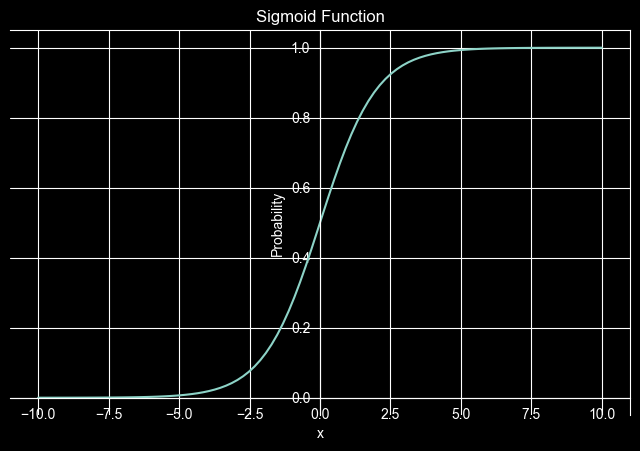

In [285]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, y)

plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Probability")

plt.grid(True)

ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

plt.show()

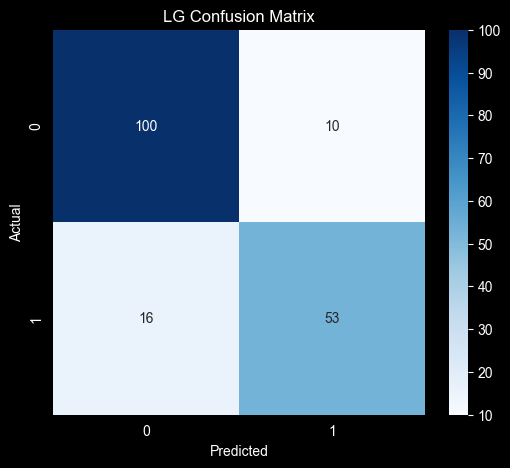

In [286]:
cm = confusion_matrix(y_val, y_Valpredict)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LG Confusion Matrix")
plt.show()

**Compare Models**

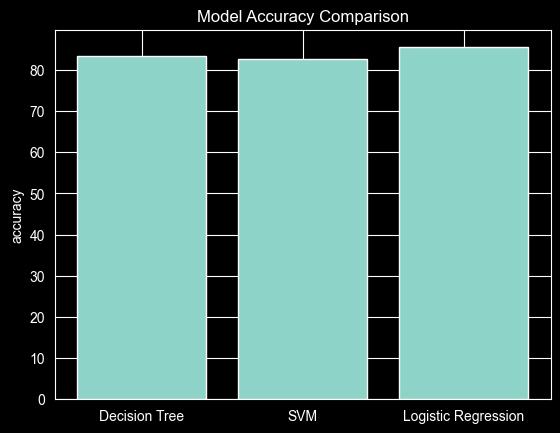

In [287]:
models = ['Decision Tree', 'SVM', 'Logistic Regression']
accuracy = [83.24, 82.6816, 85.47]
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("accuracy")
plt.show()